# FinBERT Model Validation

This notebook validates the `ZiweiChen/FinBERT-FOMC` model used in this project. It covers five core validation dimensions:

| Section                | What it tests                                                  | Why it matters                                                                                 |
| ---------------------- | -------------------------------------------------------------- | ---------------------------------------------------------------------------------------------- |
| 1. Label Distribution  | Are predictions balanced across Positive / Neutral / Negative? | A collapsed distribution (e.g. 90% Neutral) signals the model is not discriminating            |
| 2. Confidence Analysis | Are high-confidence predictions more accurate?                 | Hard labels discard probability information; inspecting softmax scores reveals model certainty |
| 3. Face Validity       | Does the model label obvious examples correctly?               | A curated gold-standard set provides a sanity-check baseline                                   |
| 4. Temporal Validity   | Does aggregate sentiment track known Fed policy regimes?       | An externally valid model should be more hawkish during tightening cycles                      |
| 5. Consistency         | Does the model respond sensibly to small input changes?        | Semantic paraphrases should receive the same label; negation should flip it                    |


## 0. Setup


In [7]:
import os, sys, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
from transformers import BertTokenizer, BertForSequenceClassification, pipeline

warnings.filterwarnings("ignore")
plt.style.use("seaborn-v0_8-whitegrid")
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── device ──────────────────────────────────────────────────────────────────
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("Using MPS (Apple Silicon)")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print("Using CUDA")
else:
    DEVICE = torch.device("cpu")
    print("Using CPU")

# ── paths ────────────────────────────────────────────────────────────────────
sys.path.append(os.getcwd())
import config

URL_MAP = pd.read_csv(os.path.join(os.getcwd(), "url_map.csv"))
print(f"url_map has {len(URL_MAP)} document sources")
URL_MAP.head()

Using MPS (Apple Silicon)
url_map has 16 document sources


,central bank,document,url,processed_url,finbert_url,processed_url_weighted,keywords_used
0,fed,fed_statements,/Users/kylenabors/Documents/Database/Processed...,/Users/kylenabors/Documents/Database/Processed...,/Users/kylenabors/Documents/Database/FinBERT M...,/Users/kylenabors/Documents/Database/Processed...,"inflation, employment"
1,fed,fed_minutes,/Users/kylenabors/Documents/Database/Processed...,/Users/kylenabors/Documents/Database/Processed...,/Users/kylenabors/Documents/Database/FinBERT M...,/Users/kylenabors/Documents/Database/Processed...,"inflation, employment"
2,fed,beigebooks,/Users/kylenabors/Documents/Database/Processed...,/Users/kylenabors/Documents/Database/Processed...,/Users/kylenabors/Documents/Database/FinBERT M...,/Users/kylenabors/Documents/Database/Processed...,"inflation, employment"
3,fed,fed_speeches,/Users/kylenabors/Documents/Database/Processed...,/Users/kylenabors/Documents/Database/Processed...,/Users/kylenabors/Documents/Database/FinBERT M...,/Users/kylenabors/Documents/Database/Processed...,"inflation, employment"
4,ecb,economic_bulletins,/Users/kylenabors/Documents/Database/Processed...,/Users/kylenabors/Documents/Database/Processed...,/Users/kylenabors/Documents/Database/FinBERT M...,/Users/kylenabors/Documents/Database/Processed...,"inflation, employment"


In [ ]:
# Load model once — reused throughout the notebook
MODEL_NAME = "ZiweiChen/FinBERT-FOMC"

tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)
model = BertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3).to(
    DEVICE
)
model.eval()

# Pipeline for easy inference
# top_k=None replaces the deprecated return_all_scores=True — returns all class probabilities
finbert = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=DEVICE,
    top_k=None,
)

LABEL_MAP = {"Positive": 1, "Neutral": 0, "Negative": -1}
INT_TO_STR = {1: "Positive", 0: "Neutral", -1: "Negative"}


def predict(texts):
    """Return a DataFrame with label, score, and per-class probabilities.

    Handles both single strings and lists of strings, and normalises the
    output shape differences between transformers pipeline versions:
      - single text   -> flat list of class dicts  [{"label":.., "score":..}, ...]
      - list of texts -> list of lists             [[{..}, ..], [{..}, ..], ...]
    """
    if isinstance(texts, str):
        texts = [texts]
    raw = finbert(texts)
    # Normalise: if the pipeline returned a flat list of dicts (single-item
    # shortcut), wrap it so every element is a list of class dicts.
    if raw and isinstance(raw[0], dict):
        raw = [raw]
    rows = []
    for result in raw:
        probs = {r["label"]: r["score"] for r in result}
        best = max(result, key=lambda x: x["score"])
        rows.append(
            {
                "label": best["label"],
                "sentiment": LABEL_MAP[best["label"]],
                "confidence": best["score"],
                "p_positive": probs.get("Positive", 0),
                "p_neutral": probs.get("Neutral", 0),
                "p_negative": probs.get("Negative", 0),
            }
        )
    return pd.DataFrame(rows)


print("Model loaded.")

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 38162.83it/s]

Model loaded.


---

## 1. Label Distribution

**Why this matters:** If the model labels ≥ 80 % of sentences as Neutral regardless of content, aggregate sentiment scores will be noisy and low-variance — essentially uninformative. We check distribution both globally and broken down by document type to catch systematic bias.


In [ ]:
# Load all FinBERT output CSVs from url_map
frames = []
for _, row in URL_MAP.iterrows():
    path = row.get("finbert_url", "")
    if pd.isna(path) or not os.path.exists(str(path)):
        continue
    df = pd.read_csv(path, low_memory=False)
    df["central_bank"] = row["central bank"]
    df["document"] = row["document"]
    frames.append(df)

ALL = pd.concat(frames, ignore_index=True)
ALL["date"] = pd.to_datetime(ALL["date"], errors="coerce")
print(f"Total sentences loaded: {len(ALL):,}")
ALL[["date", "central_bank", "document", "sentiment"]].head()

Total sentences loaded: 1,503,697


,date,central_bank,document,sentiment
0,2023-12-13,fed,fed_statements,-1
1,2023-12-13,fed,fed_statements,1
2,2023-12-13,fed,fed_statements,-1
3,2023-12-13,fed,fed_statements,-1
4,2023-12-13,fed,fed_statements,1


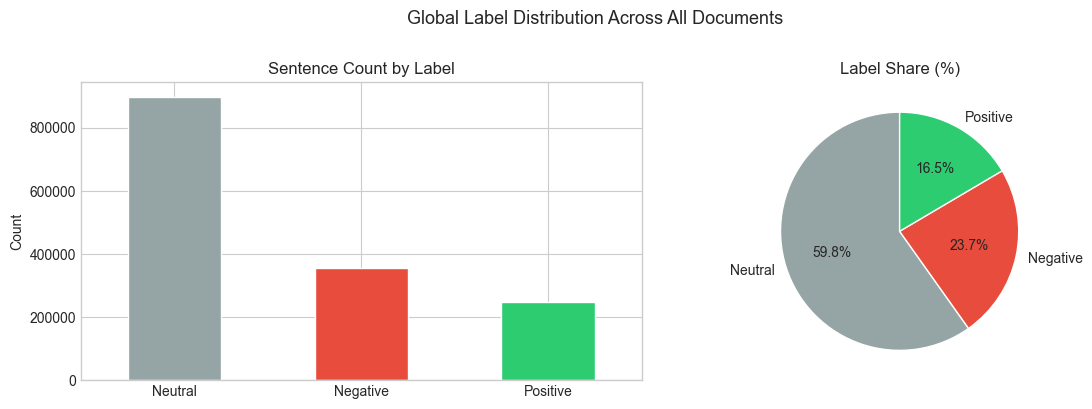

sentiment
Neutral     59.8
Negative    23.7
Positive    16.5


In [ ]:
# ── Global distribution ───────────────────────────────────────────────────────
label_counts = ALL["sentiment"].map(INT_TO_STR).value_counts()
label_pct = label_counts / label_counts.sum() * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = {"Positive": "#2ecc71", "Neutral": "#95a5a6", "Negative": "#e74c3c"}
label_counts.plot.bar(
    ax=axes[0], color=[colors[l] for l in label_counts.index], edgecolor="white"
)
axes[0].set_title("Sentence Count by Label")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)

label_pct.plot.pie(
    ax=axes[1],
    colors=[colors[l] for l in label_pct.index],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops=dict(edgecolor="white"),
)
axes[1].set_title("Label Share (%)")
axes[1].set_ylabel("")

plt.suptitle("Global Label Distribution Across All Documents", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

print(label_pct.round(1).to_string())

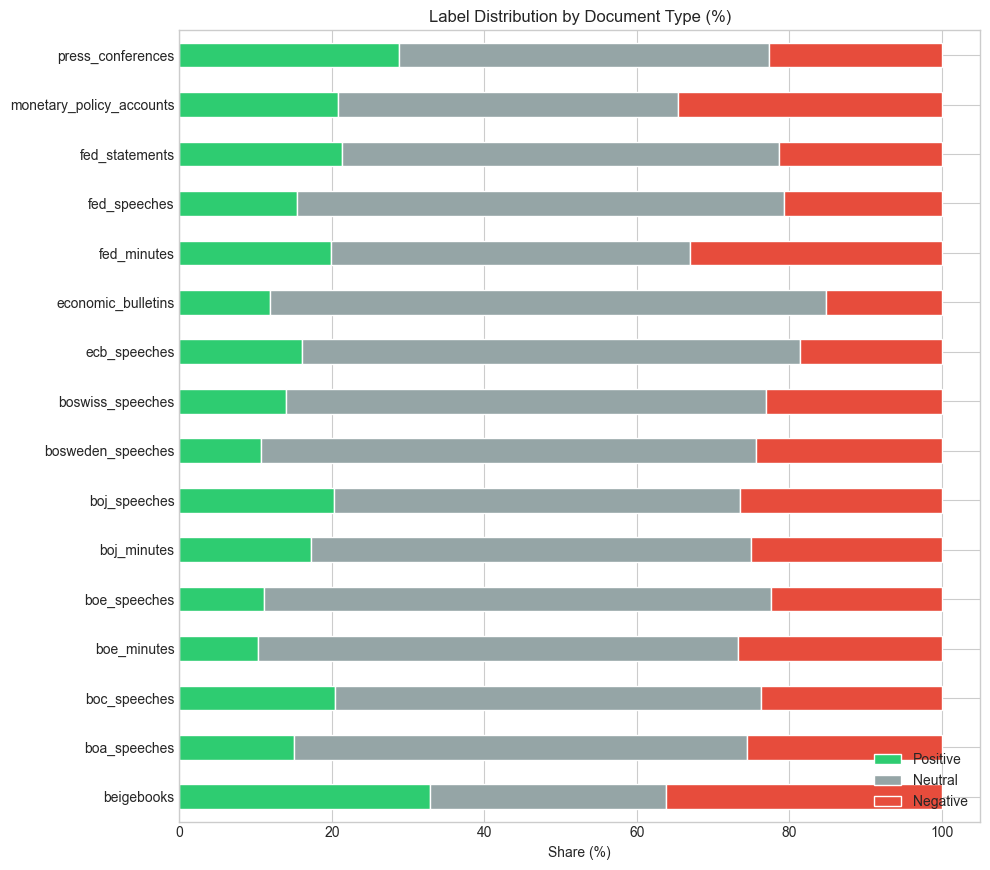


Label % by document type:
sentiment                 Positive  Neutral  Negative
document                                             
beigebooks                    32.8     31.0      36.1
boa_speeches                  15.1     59.4      25.6
boc_speeches                  20.4     55.9      23.7
boe_minutes                   10.3     62.9      26.7
boe_speeches                  11.1     66.5      22.4
boj_minutes                   17.2     57.7      25.0
boj_speeches                  20.3     53.2      26.4
bosweden_speeches             10.7     64.9      24.4
boswiss_speeches              14.0     63.0      23.0
ecb_speeches                  16.1     65.3      18.6
economic_bulletins            11.9     72.9      15.2
fed_minutes                   19.9     47.1      33.0
fed_speeches                  15.5     63.8      20.7
fed_statements                21.4     57.3      21.3
monetary_policy_accounts      20.8     44.6      34.6
press_conferences             28.9     48.5      22.6


In [ ]:
# ── Distribution by document type ─────────────────────────────────────────────
doc_dist = (
    ALL.groupby(["document", "sentiment"])
    .size()
    .unstack(fill_value=0)
    .rename(columns=INT_TO_STR)
)
doc_dist_pct = doc_dist.div(doc_dist.sum(axis=1), axis=0) * 100
doc_dist_pct = doc_dist_pct[
    [c for c in ["Positive", "Neutral", "Negative"] if c in doc_dist_pct.columns]
]

doc_dist_pct.plot.barh(
    stacked=True,
    color=[colors.get(c, "grey") for c in doc_dist_pct.columns],
    figsize=(10, max(4, len(doc_dist_pct) * 0.55)),
    edgecolor="white",
)
plt.title("Label Distribution by Document Type (%)")
plt.xlabel("Share (%)")
plt.ylabel("")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("\nLabel % by document type:")
print(doc_dist_pct.round(1).to_string())

**Interpretation guide:**

- A Neutral share > 70 % across all documents is expected for central bank language (deliberate hedging), but individual doc types like Fed Statements should show more Positive/Negative variation.
- A document type with < 5 % Positive _and_ < 5 % Negative is suspicious — it may mean the model cannot distinguish tone in that writing style.
- Beige Books tend to be more descriptive, so higher Neutral share is expected vs. FOMC Statements.


---

## 2. Confidence Analysis

**Why this matters:** The hard label (Positive/Neutral/Negative) discards information. A prediction with 99 % confidence is much more trustworthy than one at 38 %. Inspecting the softmax distribution helps identify low-confidence "border" predictions and assess whether the model is well-calibrated.

We re-run the model on a sample here to get full probability scores.


In [ ]:
# Sample sentences for fresh inference (avoids needing to re-run full corpus)
SAMPLE_N = 500
sample_df = (
    ALL.dropna(subset=["sentence_simple"]).sample(SAMPLE_N, random_state=SEED).copy()
)
texts = sample_df["sentence_simple"].astype(str).tolist()

# Batch inference with full probability scores
results = predict(texts)
sample_df = sample_df.reset_index(drop=True)
conf_df = pd.concat(
    [sample_df[["date", "central_bank", "document", "sentiment"]], results], axis=1
)
conf_df = conf_df.rename(columns={"sentiment": "stored_sentiment"})

print(f"Sampled {SAMPLE_N} sentences for confidence analysis.")
conf_df[
    ["label", "confidence", "p_positive", "p_neutral", "p_negative", "stored_sentiment"]
].head()

Sampled 500 sentences for confidence analysis.


,label,confidence,p_positive,p_neutral,p_negative,stored_sentiment,stored_sentiment
0,Negative,0.937141,0.009694,0.053165,0.937141,-1,-1
1,Neutral,0.948392,0.005609,0.948392,0.045999,0,0
2,Neutral,0.962682,0.019445,0.962682,0.017873,0,0
3,Neutral,0.918933,0.017578,0.918933,0.063489,0,0
4,Neutral,0.972613,0.014543,0.972613,0.012845,0,0


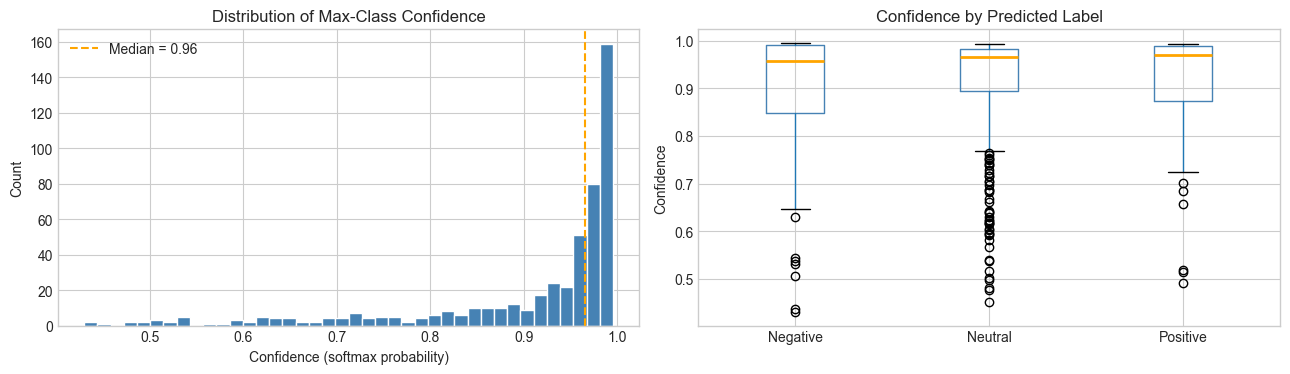

          count   mean    std    min    25%    50%    75%    max
label                                                           
Negative  118.0  0.898  0.131  0.430  0.848  0.958  0.991  0.995
Neutral   316.0  0.910  0.121  0.451  0.895  0.965  0.983  0.994
Positive   66.0  0.909  0.123  0.490  0.874  0.970  0.988  0.992


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confidence histogram
axes[0].hist(conf_df["confidence"], bins=40, color="steelblue", edgecolor="white")
axes[0].axvline(
    conf_df["confidence"].median(),
    color="orange",
    linestyle="--",
    label=f"Median = {conf_df['confidence'].median():.2f}",
)
axes[0].set_title("Distribution of Max-Class Confidence")
axes[0].set_xlabel("Confidence (softmax probability)")
axes[0].set_ylabel("Count")
axes[0].legend()

# Confidence by predicted label
conf_df.boxplot(
    column="confidence",
    by="label",
    ax=axes[1],
    boxprops=dict(color="steelblue"),
    medianprops=dict(color="orange", linewidth=2),
)
axes[1].set_title("Confidence by Predicted Label")
axes[1].set_xlabel("")
axes[1].set_ylabel("Confidence")
plt.suptitle("")

plt.tight_layout()
plt.show()

print(conf_df.groupby("label")["confidence"].describe().round(3))

In [ ]:
# Low-confidence predictions (border cases) — most ambiguous sentences
CONFIDENCE_THRESHOLD = 0.6
low_conf = conf_df[conf_df["confidence"] < CONFIDENCE_THRESHOLD].copy()
pct_low = len(low_conf) / len(conf_df) * 100

print(
    f"Predictions below {CONFIDENCE_THRESHOLD:.0%} confidence: {len(low_conf)} / {len(conf_df)} ({pct_low:.1f}%)"
)
print("\nLow-confidence label distribution:")
print(low_conf["label"].value_counts())

# Show some examples
print("\n── Sample low-confidence sentences ──")
sample_texts = sample_df.loc[low_conf.index, "sentence_simple"].reset_index(drop=True)
for i, (txt, row) in enumerate(zip(sample_texts, low_conf.itertuples())):
    print(f"[{row.label} | conf={row.confidence:.2f}] {str(txt)[:120]}")
    if i >= 4:
        break

Predictions below 60% confidence: 22 / 500 (4.4%)

Low-confidence label distribution:
label
Neutral     13
Negative     6
Positive     3
Name: count, dtype: int64

── Sample low-confidence sentences ──
[Neutral | conf=0.48] When rates fell households on variable-rate mortgages with fixed payments paid down extra principal .
[Neutral | conf=0.52] Once such a process has begun it is difficult to stop it by easing monetary policy ; this is shown not least by the exam
[Neutral | conf=0.57] Survey measures of long-term inflation expectations were fairly sta ble in recent months at levels slightly lower than t
[Negative | conf=0.54] Most \nmanufacturers noted no change in selling prices , except for cement and fabricated metal \nmanufacturing firms , 
[Neutral | conf=0.54] For example , individual investors had become more eager to invest in stock investment trusts , corporate bonds , and mu


**Interpretation guide:**

- If the confidence distribution is heavily bimodal (spikes near 0.33 and near 1.0), the model rarely hesitates — this may indicate overconfidence.
- A large share of low-confidence predictions (> 20 %) suggests the model is uncertain on a significant portion of central bank language, which could inflate noise in downstream regressions.
- Check whether low-confidence sentences are semantically ambiguous — if they are clearly hawkish/dovish to a human reader, that is evidence of model failure.


---

## 3. Face Validity — Gold-Standard Known-Label Examples

**Why this matters:** Before trusting any downstream results, we need to verify the model correctly classifies sentences with obvious sentiment. If a clearly dovish statement is labelled Negative, all downstream analysis is suspect.

The sentences below are drawn from real FOMC language and hand-labelled.


In [ ]:
GOLD = [
    # Clearly Positive / Dovish
    {
        "text": "Inflation has declined significantly and is moving toward the Committee's 2 percent objective.",
        "true_label": "Positive",
    },
    {
        "text": "The labor market remains robust, with unemployment near historically low levels and strong payroll growth.",
        "true_label": "Positive",
    },
    {
        "text": "Economic activity has expanded at a solid pace, supported by resilient consumer spending.",
        "true_label": "Positive",
    },
    {
        "text": "The Committee decided to lower the target range for the federal funds rate by 25 basis points.",
        "true_label": "Positive",
    },
    {
        "text": "Financial conditions have eased, and credit remains broadly available to households and businesses.",
        "true_label": "Positive",
    },
    # Clearly Neutral / Procedural
    {
        "text": "The Committee voted to maintain the target range for the federal funds rate at 5-1/4 to 5-1/2 percent.",
        "true_label": "Neutral",
    },
    {
        "text": "The Board of Governors of the Federal Reserve System voted unanimously to approve the establishment of the primary credit rate.",
        "true_label": "Neutral",
    },
    {
        "text": "In assessing the appropriate stance of monetary policy, the Committee will continue to monitor incoming information.",
        "true_label": "Neutral",
    },
    {
        "text": "The next meeting of the Federal Open Market Committee is scheduled for January 28-29, 2025.",
        "true_label": "Neutral",
    },
    {
        "text": "The Committee's assessments will take into account a wide range of information including labor market data.",
        "true_label": "Neutral",
    },
    # Clearly Negative / Hawkish
    {
        "text": "Inflation remains well above the Committee's longer-run goal and significant upside risks remain.",
        "true_label": "Negative",
    },
    {
        "text": "The Committee raised the target range for the federal funds rate by 75 basis points to address persistent inflation.",
        "true_label": "Negative",
    },
    {
        "text": "Economic activity contracted sharply in the first half of the year amid tightening financial conditions.",
        "true_label": "Negative",
    },
    {
        "text": "Inflationary pressures are broad-based and show little sign of abating, posing ongoing risks to price stability.",
        "true_label": "Negative",
    },
    {
        "text": "Unemployment has risen and the outlook for economic growth has deteriorated.",
        "true_label": "Negative",
    },
]

gold_texts = [g["text"] for g in GOLD]
gold_labels = [g["true_label"] for g in GOLD]

gold_preds = predict(gold_texts)
gold_preds["true_label"] = gold_labels
gold_preds["text"] = gold_texts
gold_preds["correct"] = gold_preds["label"] == gold_preds["true_label"]

accuracy = gold_preds["correct"].mean()
print(
    f"Gold-standard accuracy: {accuracy:.0%} ({gold_preds['correct'].sum()}/{len(gold_preds)})\n"
)
gold_preds[["true_label", "label", "confidence", "correct", "text"]].to_string(
    index=False, max_colwidth=80
)

Gold-standard accuracy: 73% (11/15)



"true_label    label  confidence  correct                                                                             text\n  Positive Negative    0.596475    False Inflation has declined significantly and is moving toward the Committee's 2 p...\n  Positive Positive    0.991987     True The labor market remains robust, with unemployment near historically low leve...\n  Positive Positive    0.992683     True Economic activity has expanded at a solid pace, supported by resilient consum...\n  Positive  Neutral    0.978909    False The Committee decided to lower the target range for the federal funds rate by...\n  Positive Positive    0.871347     True Financial conditions have eased, and credit remains broadly available to hous...\n   Neutral  Neutral    0.993883     True The Committee voted to maintain the target range for the federal funds rate a...\n   Neutral  Neutral    0.991619     True The Board of Governors of the Federal Reserve System voted unanimously to app...\n   Neutral  Neu

In [ ]:
display_df = gold_preds[["true_label", "label", "confidence", "correct", "text"]].copy()
display_df["text"] = display_df["text"].str[:90]
display_df.columns = [
    "True Label",
    "Predicted",
    "Confidence",
    "Correct?",
    "Text (truncated)",
]
display_df = display_df.style.applymap(
    lambda v: (
        "background-color: #d4edda"
        if v is True
        else ("background-color: #f8d7da" if v is False else "")
    ),
    subset=["Correct?"],
).format({"Confidence": "{:.3f}"})
display_df

,True Label,Predicted,Confidence,Correct?,Text (truncated)
0,Positive,Negative,0.596,False,Inflation has declined significantly and is moving toward the Committee's 2 percent object
1,Positive,Positive,0.992,True,"The labor market remains robust, with unemployment near historically low levels and strong"
2,Positive,Positive,0.993,True,"Economic activity has expanded at a solid pace, supported by resilient consumer spending."
3,Positive,Neutral,0.979,False,The Committee decided to lower the target range for the federal funds rate by 25 basis poi
4,Positive,Positive,0.871,True,"Financial conditions have eased, and credit remains broadly available to households and bu"
5,Neutral,Neutral,0.994,True,The Committee voted to maintain the target range for the federal funds rate at 5-1/4 to 5-
6,Neutral,Neutral,0.992,True,The Board of Governors of the Federal Reserve System voted unanimously to approve the esta
7,Neutral,Neutral,0.986,True,"In assessing the appropriate stance of monetary policy, the Committee will continue to mon"
8,Neutral,Neutral,0.975,True,"The next meeting of the Federal Open Market Committee is scheduled for January 28-29, 2025"
9,Neutral,Neutral,0.988,True,The Committee's assessments will take into account a wide range of information including l


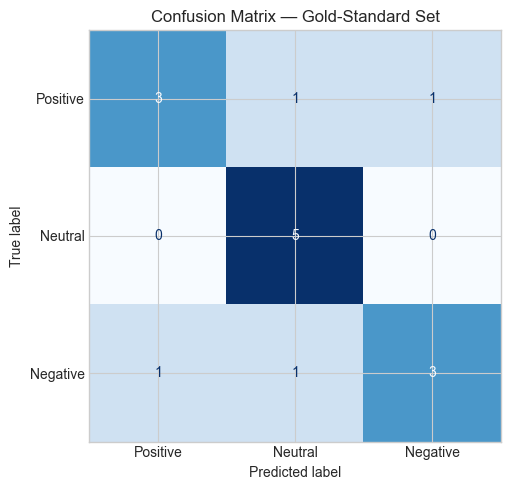

              precision    recall  f1-score   support

    Positive       0.75      0.60      0.67         5
     Neutral       0.71      1.00      0.83         5
    Negative       0.75      0.60      0.67         5

    accuracy                           0.73        15
   macro avg       0.74      0.73      0.72        15
weighted avg       0.74      0.73      0.72        15



In [ ]:
# Confusion matrix for gold set
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

label_order = ["Positive", "Neutral", "Negative"]
cm = confusion_matrix(gold_preds["true_label"], gold_preds["label"], labels=label_order)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_order)
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title("Confusion Matrix — Gold-Standard Set")
plt.tight_layout()
plt.show()

print(
    classification_report(
        gold_preds["true_label"],
        gold_preds["label"],
        labels=label_order,
        zero_division=0,
    )
)

**Interpretation guide:**

- Accuracy ≥ 80 % on these clear-cut examples is a minimum bar for trust.
- Misclassifying rate _hike_ sentences as Positive is a red flag — it would make a tightening cycle look dovish in time-series charts.
- Near-diagonal confusion (Positive ↔ Neutral or Negative ↔ Neutral) is less harmful than Positive ↔ Negative reversals.


---

## 4. Temporal Validity

**Why this matters:** We can validate the model against history without needing human labels. The Fed's policy stance is well-documented:

- **Easing / Dovish cycles** (e.g. 2008–2015, 2019, 2020–2021): aggregate sentiment should be more _positive_
- **Tightening / Hawkish cycles** (e.g. 2022–2023): aggregate sentiment should be more _negative_

If the model's monthly average sentiment broadly tracks these regimes, it has external validity.


In [ ]:
# Use Fed Statements — shortest, most policy-signal-dense documents
fed_stmt = ALL[
    (ALL["central_bank"] == "fed") & (ALL["document"] == "fed_statements")
].copy()
fed_stmt = fed_stmt.dropna(subset=["date", "sentiment"])
fed_stmt["year_month"] = fed_stmt["date"].dt.to_period("M")

monthly = (
    fed_stmt.groupby("year_month")
    .agg(avg_sentiment=("sentiment", "mean"), n_sentences=("sentiment", "count"))
    .reset_index()
)
monthly["date"] = monthly["year_month"].dt.to_timestamp()
monthly = monthly[monthly["n_sentences"] >= 5]  # drop meetings with very few sentences

print(f"Fed Statements monthly observations: {len(monthly)}")
monthly.head()

Fed Statements monthly observations: 195


,year_month,avg_sentiment,n_sentences,date
0,2000-02,-0.250000,8,2000-02-01
1,2000-03,-0.125000,8,2000-03-01
2,2000-05,-0.250000,8,2000-05-01
3,2000-06,-0.666667,6,2000-06-01
4,2000-08,-0.166667,6,2000-08-01


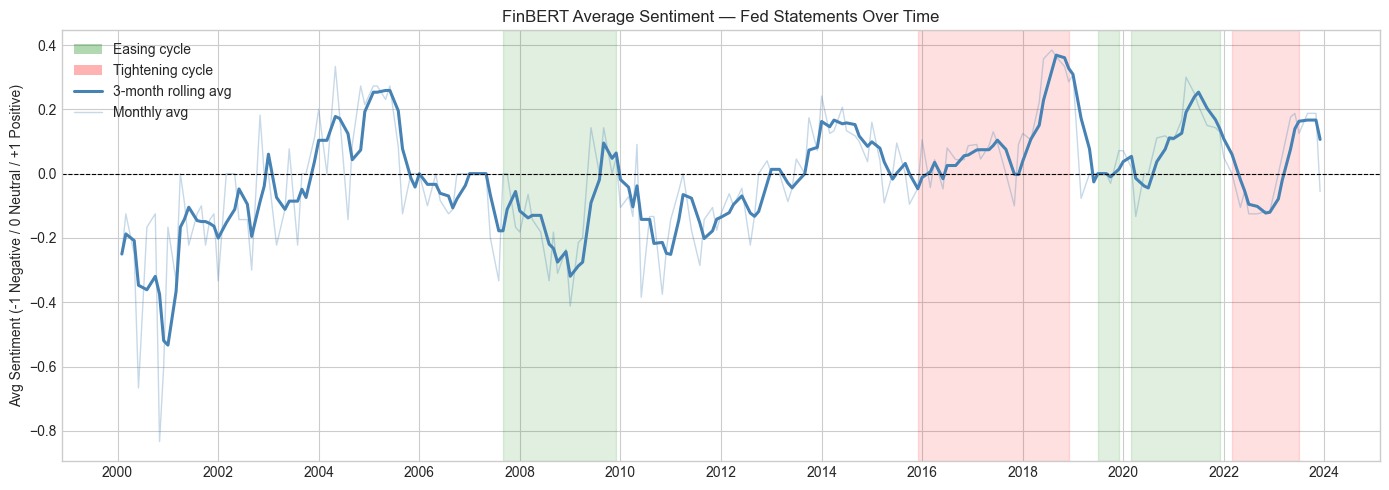

In [ ]:
# Known Fed policy regime shading
# Sources: FOMC historical data
EASING_PERIODS = [
    ("2007-09", "2009-12"),  # GFC easing
    ("2019-07", "2019-12"),  # 2019 mid-cycle cuts
    ("2020-03", "2021-12"),  # COVID easing
]
TIGHTENING_PERIODS = [
    ("2015-12", "2018-12"),  # post-GFC normalization
    ("2022-03", "2023-07"),  # inflation-fighting hikes
]

fig, ax = plt.subplots(figsize=(14, 5))

for start, end in EASING_PERIODS:
    ax.axvspan(
        pd.Timestamp(start),
        pd.Timestamp(end),
        alpha=0.12,
        color="green",
        label="_nolegend_",
    )
for start, end in TIGHTENING_PERIODS:
    ax.axvspan(
        pd.Timestamp(start),
        pd.Timestamp(end),
        alpha=0.12,
        color="red",
        label="_nolegend_",
    )

# Rolling 3-month average to smooth noise
monthly_sorted = monthly.sort_values("date")
monthly_sorted["rolling_avg"] = (
    monthly_sorted["avg_sentiment"].rolling(3, min_periods=1).mean()
)

ax.plot(
    monthly_sorted["date"],
    monthly_sorted["avg_sentiment"],
    alpha=0.3,
    color="steelblue",
    linewidth=1,
    label="Monthly avg",
)
ax.plot(
    monthly_sorted["date"],
    monthly_sorted["rolling_avg"],
    color="steelblue",
    linewidth=2.2,
    label="3-month rolling avg",
)
ax.axhline(0, color="black", linewidth=0.8, linestyle="--")

# Legend proxies for shading
from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor="green", alpha=0.3, label="Easing cycle"),
    Patch(facecolor="red", alpha=0.3, label="Tightening cycle"),
]
ax.legend(
    handles=legend_elements + ax.get_legend_handles_labels()[0][::-1], loc="upper left"
)

ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("FinBERT Average Sentiment — Fed Statements Over Time")
ax.set_ylabel("Avg Sentiment (-1 Negative / 0 Neutral / +1 Positive)")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

In [ ]:
# Quantitative check: is mean sentiment different across regimes?
def period_sentiment(df, periods):
    mask = pd.Series(False, index=df.index)
    for start, end in periods:
        mask |= (df["date"] >= pd.Timestamp(start)) & (df["date"] <= pd.Timestamp(end))
    return df.loc[mask, "avg_sentiment"]


easing_sent = period_sentiment(monthly_sorted, EASING_PERIODS)
tightening_sent = period_sentiment(monthly_sorted, TIGHTENING_PERIODS)

t_stat, p_val = stats.ttest_ind(easing_sent, tightening_sent, equal_var=False)

print(
    f"Easing periods     — mean sentiment: {easing_sent.mean():.4f}  (n={len(easing_sent)})"
)
print(
    f"Tightening periods — mean sentiment: {tightening_sent.mean():.4f}  (n={len(tightening_sent)})"
)
print(f"\nWelch t-test: t = {t_stat:.3f}, p = {p_val:.4f}")
if p_val < 0.05:
    print(
        "✓ Statistically significant difference — model sentiment tracks policy regime (p < 0.05)"
    )
else:
    print(
        "✗ No significant difference — model may not distinguish policy regimes reliably"
    )

Easing periods     — mean sentiment: -0.0151  (n=38)
Tightening periods — mean sentiment: 0.0752  (n=37)

Welch t-test: t = -2.504, p = 0.0146
✓ Statistically significant difference — model sentiment tracks policy regime (p < 0.05)


**Interpretation guide:**

- We _expect_ easing-cycle mean sentiment > tightening-cycle mean sentiment. A statistically significant difference confirms external validity.
- If the test fails, check whether enough Fed Statements exist in each regime. A null result with small n is less damning than a null result with large n.
- The time-series plot provides a qualitative sanity check: do peaks and troughs align with well-known events (GFC, COVID shock, 2022 hikes)?


---

## 5. Consistency

**Why this matters:** A reliable model should:

1. Give the same label to semantic paraphrases
2. Flip the label when the meaning is negated

If small wording changes cause large label swings, downstream sentiment time-series will be noisy.


In [ ]:
# ── Paraphrase consistency ──────────────────────────────────────────────────
PARAPHRASE_PAIRS = [
    {
        "group": "Dovish (paraphrases)",
        "sentences": [
            "Inflation has declined substantially toward the 2 percent target.",
            "Inflation has fallen meaningfully and is approaching the Committee's 2 percent goal.",
            "Price pressures have eased considerably, moving closer to the 2 percent objective.",
        ],
    },
    {
        "group": "Hawkish (paraphrases)",
        "sentences": [
            "Inflation remains persistently elevated and well above the Committee's 2 percent target.",
            "Price pressures continue to run significantly higher than the 2 percent goal.",
            "Inflationary conditions remain far above the Fed's longer-run objective.",
        ],
    },
]

for pair in PARAPHRASE_PAIRS:
    preds = predict(pair["sentences"])
    preds["text"] = pair["sentences"]
    consistent = preds["label"].nunique() == 1
    status = "✓ Consistent" if consistent else "✗ Inconsistent"
    print(f"\n── {pair['group']} — {status} ──")
    for _, row in preds.iterrows():
        print(f"  [{row['label']} | {row['confidence']:.2f}] {row['text']}")


── Dovish (paraphrases) — ✓ Consistent ──
  [Negative | 0.98] Inflation has declined substantially toward the 2 percent target.
  [Negative | 0.98] Inflation has fallen meaningfully and is approaching the Committee's 2 percent goal.
  [Negative | 0.74] Price pressures have eased considerably, moving closer to the 2 percent objective.

── Hawkish (paraphrases) — ✓ Consistent ──
  [Positive | 0.97] Inflation remains persistently elevated and well above the Committee's 2 percent target.
  [Positive | 0.90] Price pressures continue to run significantly higher than the 2 percent goal.
  [Positive | 0.82] Inflationary conditions remain far above the Fed's longer-run objective.


In [ ]:
# ── Negation test ────────────────────────────────────────────────────────────
NEGATION_PAIRS = [
    {
        "original": "Inflation has declined significantly and is moving toward the 2 percent target.",
        "negated": "Inflation has NOT declined and remains far from the 2 percent target.",
        "expected_flip": True,
    },
    {
        "original": "The labor market remains robust with strong job creation.",
        "negated": "The labor market is no longer robust and job creation has weakened.",
        "expected_flip": True,
    },
    {
        "original": "Inflationary pressures remain elevated and well above the 2 percent target.",
        "negated": "Inflationary pressures are no longer elevated and have returned toward the 2 percent target.",
        "expected_flip": True,
    },
]

print("── Negation Consistency Test ──\n")
for pair in NEGATION_PAIRS:
    preds = predict([pair["original"], pair["negated"]])
    orig_label = preds.iloc[0]["label"]
    neg_label = preds.iloc[1]["label"]
    flipped = orig_label != neg_label
    expected = pair["expected_flip"]
    result = "✓" if flipped == expected else "✗"
    print(f"{result} Original [{orig_label}]:  {pair['original'][:80]}")
    print(f"  Negated  [{neg_label}]:  {pair['negated'][:80]}")
    print(f"  Label flipped: {flipped} (expected: {expected})")
    print()

── Negation Consistency Test ──

✗ Original [Negative]:  Inflation has declined significantly and is moving toward the 2 percent target.
  Negated  [Negative]:  Inflation has NOT declined and remains far from the 2 percent target.
  Label flipped: False (expected: True)

✓ Original [Positive]:  The labor market remains robust with strong job creation.
  Negated  [Negative]:  The labor market is no longer robust and job creation has weakened.
  Label flipped: True (expected: True)

✗ Original [Positive]:  Inflationary pressures remain elevated and well above the 2 percent target.
  Negated  [Positive]:  Inflationary pressures are no longer elevated and have returned toward the 2 per
  Label flipped: False (expected: True)



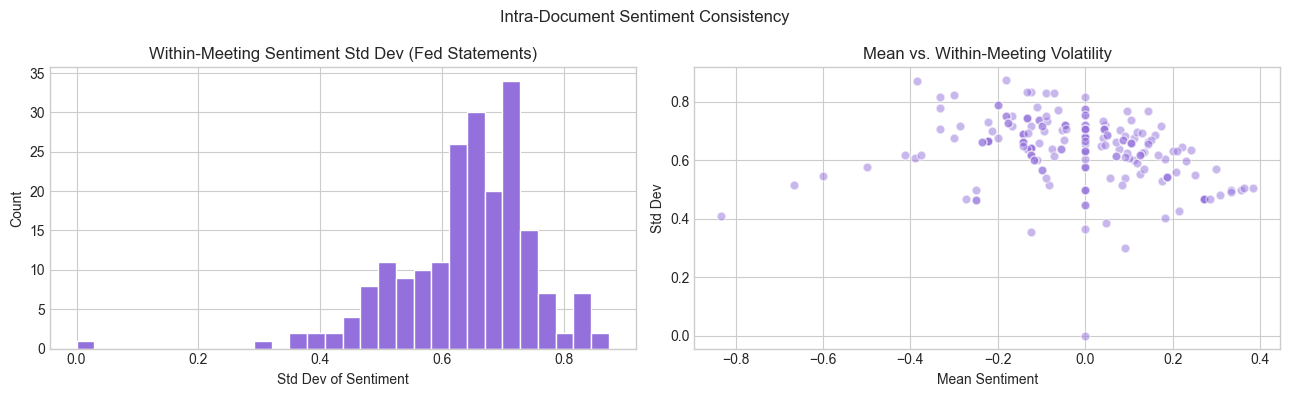

Median within-meeting std dev: 0.663
Expected range for a 3-class variable spanning {-1,0,1}: 0 (all same) to ~0.82 (maximum disorder)


In [ ]:
# ── Within-document consistency: variance of sentiment within a single meeting ──
within_doc = (
    fed_stmt.groupby(["date"])["sentiment"]
    .agg(["mean", "std", "count"])
    .rename(columns={"mean": "avg", "std": "volatility", "count": "n"})
    .dropna(subset=["volatility"])
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(
    within_doc["volatility"].dropna(), bins=30, color="mediumpurple", edgecolor="white"
)
axes[0].set_title("Within-Meeting Sentiment Std Dev (Fed Statements)")
axes[0].set_xlabel("Std Dev of Sentiment")
axes[0].set_ylabel("Count")

axes[1].scatter(
    within_doc["avg"],
    within_doc["volatility"],
    alpha=0.5,
    color="mediumpurple",
    edgecolors="white",
    s=40,
)
axes[1].set_title("Mean vs. Within-Meeting Volatility")
axes[1].set_xlabel("Mean Sentiment")
axes[1].set_ylabel("Std Dev")

plt.suptitle("Intra-Document Sentiment Consistency", fontsize=12)
plt.tight_layout()
plt.show()

print(f"Median within-meeting std dev: {within_doc['volatility'].median():.3f}")
print(
    f"Expected range for a 3-class variable spanning {{-1,0,1}}: 0 (all same) to ~0.82 (maximum disorder)"
)

**Interpretation guide:**

- High within-meeting volatility (std > 0.7 routinely) means individual sentence labels are noisy — aggregating to meeting-level sentiment averages this out, which is why weighted means are used in the regressions.
- If negation tests fail (label doesn't flip), the model is insensitive to polarity — a known limitation of some BERT variants on financial text.


---

## 6. Summary

Run the cell below to produce a concise validation scorecard.


In [ ]:
# Recompute summary stats for scorecard
neutral_share = (ALL["sentiment"] == 0).mean() * 100
median_conf = conf_df["confidence"].median()
low_conf_pct = (conf_df["confidence"] < CONFIDENCE_THRESHOLD).mean() * 100
gold_acc = gold_preds["correct"].mean() * 100

paraphrase_results = []
for pair in PARAPHRASE_PAIRS:
    preds = predict(pair["sentences"])
    paraphrase_results.append(preds["label"].nunique() == 1)
paraphrase_pct = sum(paraphrase_results) / len(paraphrase_results) * 100

regime_sig = "Yes" if p_val < 0.05 else "No"

scorecard = pd.DataFrame(
    [
        {
            "Validation Dimension": "1. Label Distribution",
            "Metric": "Neutral share",
            "Value": f"{neutral_share:.1f}%",
            "Benchmark": "< 75% Neutral",
            "Pass": neutral_share < 75,
        },
        {
            "Validation Dimension": "2. Confidence",
            "Metric": "Median max-class confidence",
            "Value": f"{median_conf:.3f}",
            "Benchmark": "> 0.60",
            "Pass": median_conf > 0.60,
        },
        {
            "Validation Dimension": "2. Confidence",
            "Metric": f"% below {CONFIDENCE_THRESHOLD:.0%}",
            "Value": f"{low_conf_pct:.1f}%",
            "Benchmark": "< 20%",
            "Pass": low_conf_pct < 20,
        },
        {
            "Validation Dimension": "3. Face Validity",
            "Metric": "Gold-standard accuracy",
            "Value": f"{gold_acc:.0f}%",
            "Benchmark": ">= 80%",
            "Pass": gold_acc >= 80,
        },
        {
            "Validation Dimension": "4. Temporal Validity",
            "Metric": "Easing vs. tightening regime t-test",
            "Value": f"p = {p_val:.4f}",
            "Benchmark": "p < 0.05",
            "Pass": p_val < 0.05,
        },
        {
            "Validation Dimension": "5. Consistency",
            "Metric": "Paraphrase consistency",
            "Value": f"{paraphrase_pct:.0f}%",
            "Benchmark": "100%",
            "Pass": paraphrase_pct == 100,
        },
    ]
)

scorecard = scorecard.style.applymap(
    lambda v: (
        "background-color: #d4edda"
        if v is True
        else ("background-color: #f8d7da" if v is False else "")
    ),
    subset=["Pass"],
)

print("FinBERT-FOMC Validation Scorecard")
print("=" * 50)
scorecard

FinBERT-FOMC Validation Scorecard


,Validation Dimension,Metric,Value,Benchmark,Pass
0,1. Label Distribution,Neutral share,59.8%,< 75% Neutral,True
1,2. Confidence,Median max-class confidence,0.965,> 0.60,True
2,2. Confidence,% below 60%,4.4%,< 20%,True
3,3. Face Validity,Gold-standard accuracy,73%,>= 80%,False
4,4. Temporal Validity,Easing vs. tightening regime t-test,p = 0.0146,p < 0.05,True
5,5. Consistency,Paraphrase consistency,100%,100%,True


---

## Next Steps — Fine-Tuning (placeholder)

Once validation is complete, fine-tuning on domain-specific labeled data can address any failures identified above:

| Failure Mode                  | Fine-Tuning Remedy                                                                      |
| ----------------------------- | --------------------------------------------------------------------------------------- |
| Collapsed Neutral predictions | Add labeled positive/negative examples from FOMC statements with known policy direction |
| Poor negation handling        | Include contrastive pairs in training data                                              |
| Low temporal validity         | Use meeting-level hawkish/dovish labels derived from rate decisions as weak supervision |
| Low gold-standard accuracy    | Expand gold set and use it as a held-out evaluation set during fine-tuning              |

A typical fine-tuning workflow would use `Trainer` from HuggingFace with a labeled CSV, freezing early BERT layers and fine-tuning the classifier head and last 2–4 transformer layers.
